# Pediatric Brain Tumor Segmentation — Full Training
**Dataset:** BraTS 2021 (1,251 patients)  
**Model:** U-Net (4-channel input, binary whole-tumor output)  
**GPU:** Colab T4  

## Before you start
1. **Runtime → Change runtime type → T4 GPU**
2. Upload your `raw/` folder to Google Drive at `My Drive/brats2021/raw/`  
   (or adjust `RAW_DRIVE_PATH` below)
3. Run all cells — training auto-resumes from the latest checkpoint if interrupted

## 1 — Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

RAW_DRIVE_PATH  = '/content/drive/MyDrive/brats2021/raw'
CKPT_DRIVE_PATH = '/content/drive/MyDrive/brats2021/checkpoints'

import os
os.makedirs(CKPT_DRIVE_PATH, exist_ok=True)

!pip install -q nibabel tqdm
!nvidia-smi

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thu Apr  2 00:05:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|          

## 2 — Process all patients to .npy
Processes raw NIfTI → Z-score normalized, middle-60% slices.  
Saves to Colab local disk (`/content/processed/`) for fast I/O.  
Skips patients already processed.

In [4]:
import nibabel as nib
import numpy as np
import json
from tqdm import tqdm
from sklearn.model_selection import train_test_split

OUT_DIR = '/content/processed'
os.makedirs(OUT_DIR, exist_ok=True)

MODALITIES = ['t1', 't1ce', 't2', 'flair']

def zscore_normalize(volume):
    mask = volume > 0
    mean = volume[mask].mean()
    std  = volume[mask].std()
    out = np.zeros_like(volume, dtype=np.float32)
    out[mask] = (volume[mask] - mean) / (std + 1e-8)
    return out

def process_patient(pid, raw_dir, out_dir):
    patient_path = os.path.join(raw_dir, pid)
    volumes = {}
    for mod in MODALITIES:
        path = os.path.join(patient_path, f'{pid}_{mod}.nii.gz')
        volumes[mod] = nib.load(path).get_fdata().astype(np.float32)
    seg = nib.load(os.path.join(patient_path, f'{pid}_seg.nii.gz')).get_fdata().astype(np.uint8)

    for mod in MODALITIES:
        volumes[mod] = zscore_normalize(volumes[mod])

    stacked = np.stack([volumes[mod] for mod in MODALITIES], axis=0)
    total = stacked.shape[2]
    start, end = int(total * 0.2), int(total * 0.8)
    stacked = stacked[:, :, :, start:end]
    seg = seg[:, :, start:end]

    np.save(os.path.join(out_dir, f'{pid}_data.npy'), stacked)
    np.save(os.path.join(out_dir, f'{pid}_seg.npy'), seg)

all_patients = sorted([
    d for d in os.listdir(RAW_DRIVE_PATH)
    if os.path.isdir(os.path.join(RAW_DRIVE_PATH, d)) and d.startswith('BraTS2021_')
])[:100] # Limit to 100 patients for processing
print(f'Found {len(all_patients)} patients (after limiting to 100)')

already_done = {f.replace('_data.npy', '') for f in os.listdir(OUT_DIR) if f.endswith('_data.npy')}
remaining = [p for p in all_patients if p not in already_done]
print(f'Processing {len(remaining)} new patients ({len(already_done)} already done)')

for pid in tqdm(remaining, desc='Processing'):
    process_patient(pid, RAW_DRIVE_PATH, OUT_DIR)

print('Processing complete!')

Found 100 patients (after limiting to 100)
Processing 97 new patients (3 already done)


Processing: 100%|██████████| 97/97 [12:35<00:00,  7.79s/it]

Processing complete!


## 3 — Train/Val/Test split

In [5]:
train_ids, temp = train_test_split(all_patients[:100], test_size=0.30, random_state=42)
val_ids, test_ids = train_test_split(temp, test_size=0.50, random_state=42)

manifest = {
    'dataset': 'BraTS2021',
    'total_patients': len(all_patients[:100]),
    'modalities': MODALITIES,
    'split': {'train': train_ids, 'val': val_ids, 'test': test_ids}
}

manifest_path = os.path.join(CKPT_DRIVE_PATH, 'manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'Split: {len(train_ids)} train | {len(val_ids)} val | {len(test_ids)} test')
print(f'Manifest saved to Drive')

Split: 70 train | 15 val | 15 test
Manifest saved to Drive


## 4 — Model, Dataset, Loss definitions

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Dataset ────────────────────────────────────────────────────────
class BraTSDataset(Dataset):
    def __init__(self, patient_ids, processed_dir):
        self.processed_dir = processed_dir
        self.slices = []
        for pid in tqdm(patient_ids, desc='Indexing'):
            data_path = os.path.join(processed_dir, f'{pid}_data.npy')
            if os.path.exists(data_path):
                n_slices = np.load(data_path, mmap_mode='r').shape[3]
                for s in range(n_slices):
                    self.slices.append((pid, s))
        print(f'Total slices: {len(self.slices)}')

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        pid, slice_idx = self.slices[idx]
        data = np.load(os.path.join(self.processed_dir, f'{pid}_data.npy'))
        seg  = np.load(os.path.join(self.processed_dir, f'{pid}_seg.npy'))
        image = data[:, :, :, slice_idx]
        mask  = (seg[:, :, slice_idx] > 0).astype(np.float32)
        return (torch.tensor(image, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.float32).unsqueeze(0))

# ── U-Net ──────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        for f in features:
            self.encoder.append(DoubleConv(in_channels, f))
            in_channels = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for layer in self.encoder:
            x = layer(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)
            x = torch.cat([skips[i // 2], x], dim=1)
            x = self.decoder[i + 1](x)
        return self.final(x)

# ── Loss & Metrics ─────────────────────────────────────────────────
class DiceBCELoss(nn.Module):
    """Combined BCE + Dice for more stable convergence."""
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred).view(-1)
        target_f = target.view(-1)
        intersection = (pred_sig * target_f).sum()
        dice_loss = 1 - (2 * intersection + self.smooth) / (pred_sig.sum() + target_f.sum() + self.smooth)
        return bce_loss + dice_loss

def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred = (torch.sigmoid(pred) > threshold).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return ((2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)).item()

print('Model and loss defined.')

Using device: cuda
Model and loss defined.


## 5 — Training with auto-resume
Checkpoints save to Google Drive every epoch.  
If Colab disconnects, just **re-run all cells** — training picks up where it left off.

In [7]:
# ── Hyperparameters ────────────────────────────────────────────────
EPOCHS     = 20
BATCH_SIZE = 16
LR         = 1e-4
NUM_WORKERS = 2

# ── Dataloaders ────────────────────────────────────────────────────
train_ds = BraTSDataset(train_ids, OUT_DIR)
val_ds   = BraTSDataset(val_ids, OUT_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── Model, optimizer, scheduler ───────────────────────────────────
model     = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = DiceBCELoss()

# ── Resume from checkpoint if available ───────────────────────────
resume_path = os.path.join(CKPT_DRIVE_PATH, 'latest_checkpoint.pth')
start_epoch = 0
best_dice   = 0.0
history     = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'lr': []}

if os.path.exists(resume_path):
    print('Resuming from checkpoint...')
    ckpt = torch.load(resume_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    best_dice   = ckpt['best_dice']
    history     = ckpt['history']
    print(f'  Resumed at epoch {start_epoch}, best Dice so far = {best_dice:.4f}')
else:
    print('Starting fresh training.')

print(f'\nConfig: {EPOCHS} epochs, batch_size={BATCH_SIZE}, lr={LR}')
print(f'Train: {len(train_ds)} slices ({len(train_loader)} batches) | '
      f'Val: {len(val_ds)} slices ({len(val_loader)} batches)')

Indexing: 100%|██████████| 70/70 [00:00<00:00, 1889.95it/s]


Total slices: 7490


Indexing: 100%|██████████| 15/15 [00:00<00:00, 2455.49it/s]

Total slices: 1605


Starting fresh training.

Config: 20 epochs, batch_size=16, lr=0.0001
Train: 7490 slices (469 batches) | Val: 1605 slices (101 batches)


In [8]:
import time

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} Train'):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss = val_dice = 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} Val'):
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            val_loss += criterion(preds, masks).item()
            val_dice += dice_score(preds, masks)

    scheduler.step()

    avg_train = train_loss / len(train_loader)
    avg_vloss = val_loss / len(val_loader)
    avg_dice  = val_dice / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_vloss)
    history['val_dice'].append(avg_dice)
    history['lr'].append(current_lr)

    print(f'\nEpoch {epoch+1}/{EPOCHS} ({elapsed/60:.1f} min) | '
          f'Train Loss={avg_train:.4f} | Val Loss={avg_vloss:.4f} | '
          f'Val Dice={avg_dice:.4f} | LR={current_lr:.2e}')

    # ── Save best model to Drive ──────────────────────────────────
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), os.path.join(CKPT_DRIVE_PATH, 'unet_best.pth'))
        print(f'  -> New best model! Dice={best_dice:.4f}')

    # ── Save resumable checkpoint to Drive every epoch ────────────
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'best_dice': best_dice,
        'history': history,
    }, resume_path)
    print(f'  Checkpoint saved to Drive.\n')

# ── Save final model ──────────────────────────────────────────────
torch.save(model.state_dict(), os.path.join(CKPT_DRIVE_PATH, 'unet_final.pth'))
print(f'\nTraining complete! Best Val Dice = {best_dice:.4f}')
print(f'Checkpoints saved to: {CKPT_DRIVE_PATH}')

Epoch 1/20 Val: 100%|██████████| 101/101 [00:59<00:00,  1.69it/s]



Epoch 1/20 (6.3 min) | Train Loss=1.4018 | Val Loss=1.2560 | Val Dice=0.7288 | LR=9.94e-05
  -> New best model! Dice=0.7288
  Checkpoint saved to Drive.



Epoch 2/20 Val: 100%|██████████| 101/101 [01:01<00:00,  1.65it/s]



Epoch 2/20 (6.1 min) | Train Loss=1.1671 | Val Loss=1.1040 | Val Dice=0.7674 | LR=9.76e-05
  -> New best model! Dice=0.7674
  Checkpoint saved to Drive.



Epoch 3/20 Val: 100%|██████████| 101/101 [00:59<00:00,  1.68it/s]


...


Epoch 18/20 (5.6 min) | Train Loss=0.0512 | Val Loss=0.4882 | Val Dice=0.8362 | LR=2.45e-06
  Checkpoint saved to Drive.



Epoch 19/20 Val: 100%|██████████| 101/101 [00:55<00:00,  1.82it/s]



Epoch 19/20 (5.6 min) | Train Loss=0.0522 | Val Loss=0.4852 | Val Dice=0.8185 | LR=6.16e-07
  Checkpoint saved to Drive.



Epoch 20/20 Val: 100%|██████████| 101/101 [00:55<00:00,  1.81it/s]



Epoch 20/20 (5.7 min) | Train Loss=0.0505 | Val Loss=0.4896 | Val Dice=0.8238 | LR=0.00e+00
  Checkpoint saved to Drive.


Training complete! Best Val Dice = 0.8528
Checkpoints saved to: /content/drive/MyDrive/brats2021/checkpoints


## 6 — Training curves

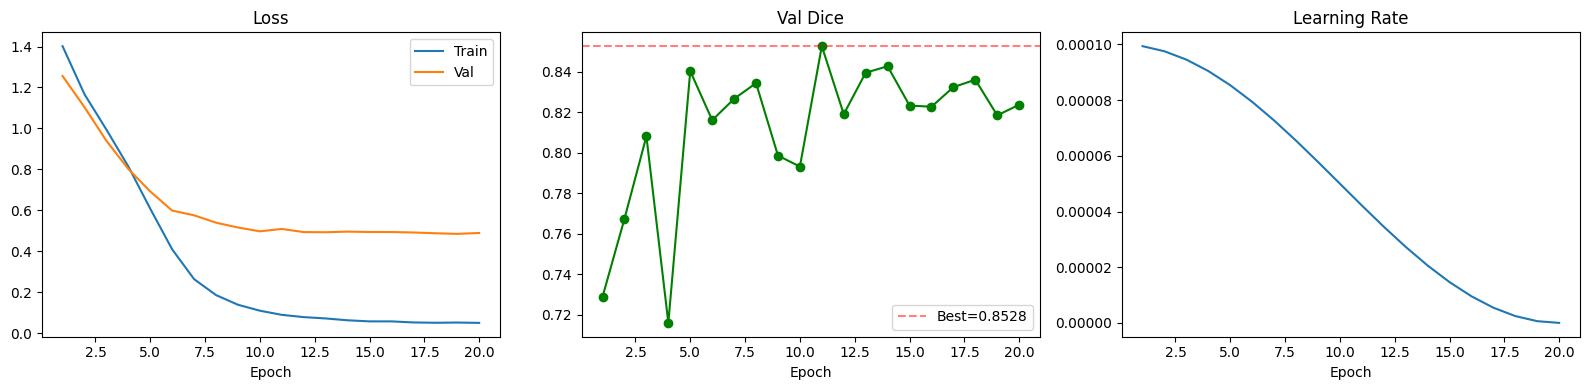

Curves saved to Drive.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['val_dice'], 'g-o')
axes[1].set_title('Val Dice'); axes[1].set_xlabel('Epoch')
axes[1].axhline(y=best_dice, color='r', linestyle='--', alpha=0.5, label=f'Best={best_dice:.4f}')
axes[1].legend()

axes[2].plot(epochs_range, history['lr'])
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
fig.savefig(os.path.join(CKPT_DRIVE_PATH, 'training_curves.png'), dpi=150)
plt.show()
print('Curves saved to Drive.')

## 7 — Evaluate on held-out test set

In [10]:
model.load_state_dict(torch.load(os.path.join(CKPT_DRIVE_PATH, 'unet_best.pth'), map_location=device))
model.eval()

test_ds = BraTSDataset(test_ids, OUT_DIR)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

test_dice = 0
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        test_dice += dice_score(preds, masks)

avg_test_dice = test_dice / len(test_loader)
print(f'\nTest Dice Score: {avg_test_dice:.4f}')

Indexing: 100%|██████████| 15/15 [00:00<00:00, 467.05it/s]


Total slices: 1605


Testing: 100%|██████████| 101/101 [01:03<00:00,  1.60it/s]


Test Dice Score: 0.8263


## 8 — Visualize sample predictions

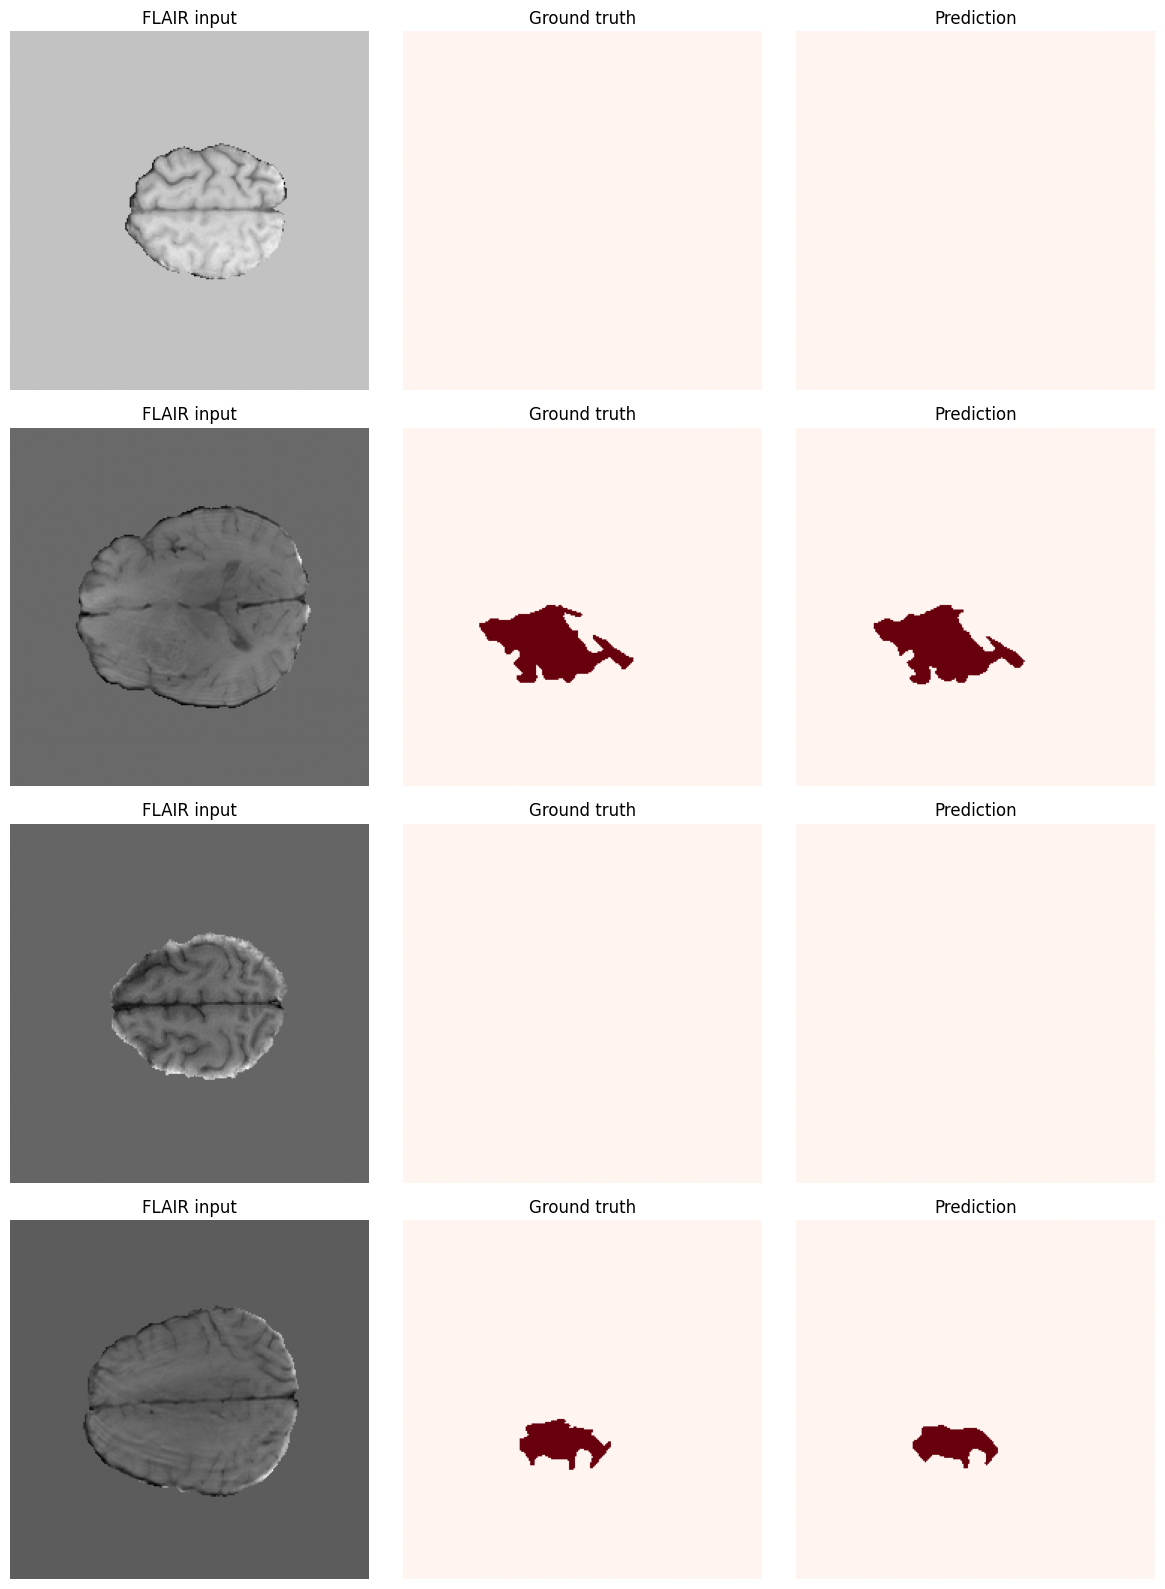

In [11]:
import random

model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row in range(4):
    idx = random.randint(0, len(test_ds) - 1)
    image, mask = test_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(image.unsqueeze(0).to(device)))
    pred_mask = (pred.squeeze().cpu() > 0.5).float()

    axes[row, 0].imshow(image[0], cmap='gray')
    axes[row, 0].set_title('FLAIR input')
    axes[row, 1].imshow(mask.squeeze(), cmap='Reds', vmin=0, vmax=1)
    axes[row, 1].set_title('Ground truth')
    axes[row, 2].imshow(pred_mask, cmap='Reds', vmin=0, vmax=1)
    axes[row, 2].set_title('Prediction')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DRIVE_PATH, 'sample_predictions.png'), dpi=150)
plt.show()

## 9 — Download best model
The best checkpoint is already on your Drive at `brats2021/checkpoints/unet_best.pth`.  
You can also download it directly:

In [12]:
from google.colab import files
files.download(os.path.join(CKPT_DRIVE_PATH, 'unet_best.pth'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>